# Compacting Rover Bounce Analysis

### Core Physical Models
1. Centrifugal Force ($F_c$)

The dynamic excitation force generated by the Eccentric Rotating Mass (ERM) is a function of the eccentric moment ($m_e r$) and the angular velocity ($\omega$):

$$F_c = m_e r \omega^2$$

2. Micro-Bounce Displacement ($X$)

Assuming the chassis acts as a rigid body under harmonic excitation, the maximum vertical displacement occurs when the upward centrifugal force exceeds the static lunar weight of the rover ($W_{moon} = m_r g_{moon}$). The maximum displacement is derived from the double integration of the net acceleration:

$$X = \frac{\max(0, F_c - W_{moon})}{m_r \omega^2}$$

3. Compaction and Relative Density ($D_r$)

Compaction of granular lunar simulant is driven by absolute dynamic stress, not the force-to-weight ratio. The achieved relative density approaches an asymptote based on the absolute applied force, where $F_{ref}$ is an empirical scaling constant for the required yielding force.

$$D_r(F_c) = D_{max} - (D_{max} - D_{min}) e^{-F_c / F_{ref}}$$

4. Ground Pressure ($P$)

Forward traction is maintained by the wheels resting on the soil. The static ground pressure is distributed across the number of wheels ($N_{wheels}$) and their contact area ($A_{wheel}$):$$P = \frac{m_r \cdot g_{moon}}{N_{wheels} \cdot A_{wheel}}$$

5. Soil Stiffness ($k_u$) and Elastic Rebound ($z_e$)

Traction is lost when the rover bounces higher than the soil's elastic rebound limit ($z_e$). Based on Hardin and Black (1968) and terramechanics unloading theories (Wong, 2001), the unloading modulus ($k_u$) of granular simulant scales quadratically with relative density. The dynamic traction limit is therefore directly tied to both the rover's mass and the soil's current compacted state.

$$k_u(D_r) = k_{u,loose} + (k_{u,dense} - k_{u,loose}) \left( \frac{D_r - D_{min}}{D_{max} - D_{min}} \right)^2$$
$$X_{limit} = z_e = \frac{P}{k_u(D_r)}$$

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors
from matplotlib.widgets import Slider

# --- 1. Physics Constants ---
g_m = 1.62  # m/s^2 (Lunar gravity)
m_r_default = 35.0  # kg (Default Rover mass)
W_m_default = m_r_default * g_m  # N (Static Lunar Weight)

# Rover Wheel Specifications
N_wheels = 6
A_wheel = 0.0025 # m^2 (e.g., 5cm x 5cm contact patch per wheel)

# --- 2. Corrected Empirical Models ---
def relative_density(Fc):
    """Density is a function of absolute force applied to the soil."""
    D_min = 0.35
    D_max = 0.95
    F_ref = 200.0  # N (Empirical force scaling for significant compaction)
    return D_max - (D_max - D_min) * np.exp(-Fc / F_ref)

def critical_rebound_limit(Dr, m_r=m_r_default):
    """Traction loss bounded by the elastic rebound of the soil matrix, dependent on rover mass."""
    # 1. Calculate Ground Pressure (P) in Pascals
    W_moon = m_r * g_m
    P_ground = W_moon / (N_wheels * A_wheel) 

    # 2. Calculate Unloading Modulus (ku) based on relative density
    ku_loose = 12e6 # 12 MN/m^3 (Loose LHS-1)
    ku_dense = 60e6 # 60 MN/m^3 (Highly compacted LHS-1)
    
    # Quadratic scaling of stiffness with relative density (Hardin & Black derived)
    ku = ku_loose + (ku_dense - ku_loose) * ((Dr - 0.35) / (0.95 - 0.35))**2
    
    # 3. Calculate Elastic Rebound (z_e) in mm
    z_e = (P_ground / ku) * 1000 
    return z_e

def micro_bounce(Fc, f, m_r=m_r_default):
    """Standard displacement formula based on Net Force and Frequency."""
    w = 2 * np.pi * f
    W_m = m_r * g_m
    F_net = np.maximum(0, Fc - W_m)
    return (F_net / (m_r * w**2)) * 1000  # Convert to mm

def micro_bounce_from_mer(mer, f, m_r=m_r_default):
    """Displacement isolated by Eccentric Moment (me * r)."""
    w = 2 * np.pi * f
    Fc = mer * w**2
    W_m = m_r * g_m
    F_net = np.maximum(0, Fc - W_m)
    return (F_net / (m_r * w**2)) * 1000

By taking the limit of the displacement equation as angular velocity approaches infinity ($\omega \to \infty$), the static lunar weight ($W_{moon}$) becomes mathematically negligible, and the $\omega^2$ terms cancel out. This reveals the absolute physical limit of the rover's bounce, entirely independent of frequency or gravity:

$$X_{max} = \lim_{\omega \to \infty} \frac{m_e r \omega^2 - W_{moon}}{m_r \omega^2} = \frac{m_e r}{m_r}$$

This defines a hard engineering constraint: sizing the internal eccentric moment ($m_e r$) correctly can mathematically guarantee the rover never exceeds the traction limit, regardless of how fast the motor spins.

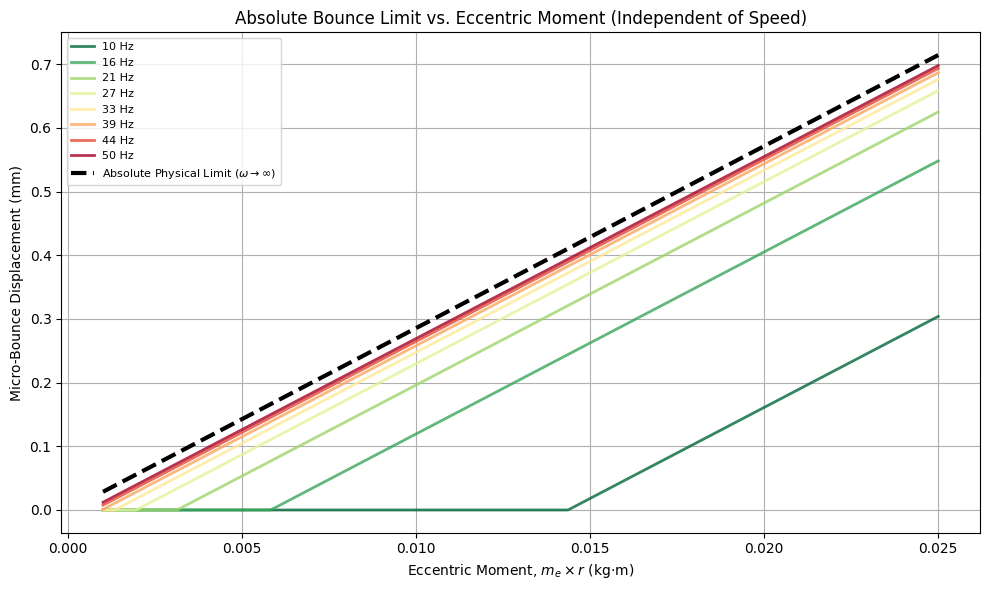

In [8]:
# PLOT A: Absolute Physical Limit (m_e * r)
mer_arr = np.linspace(0.001, 0.025, 500)
figA, axA = plt.subplots(figsize=(10, 6))

frequencies_plotA = np.linspace(10, 50, 8)
colors_plotA = plt.cm.RdYlGn_r(np.linspace(0, 1, len(frequencies_plotA)))

for freq, color in zip(frequencies_plotA, colors_plotA):
    axA.plot(mer_arr, micro_bounce_from_mer(mer_arr, freq), color=color, lw=2, label=f'{freq:.0f} Hz', alpha=0.8)

# The Asymptote
asymptote = (mer_arr / m_r_default) * 1000 
axA.plot(mer_arr, asymptote, 'k--', lw=3, label='Absolute Physical Limit ($\\omega \\rightarrow \\infty$)')

axA.set_xlabel('Eccentric Moment, $m_e \\times r$ (kg$\\cdot$m)')
axA.set_ylabel('Micro-Bounce Displacement (mm)')
axA.set_title('Absolute Bounce Limit vs. Eccentric Moment (Independent of Speed)')
axA.grid(True)
axA.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### Displacement vs. Force and Mass Independence

When mapping displacement against the absolute Centrifugal Force ($F_c$), the bounce initiates only after $F_c > W_{moon}$.However, when non-dimensionalizing the x-axis to the Force-to-Weight ratio ($F_c / W_{moon} = k$), we substitute $F_c = k m_r g_{moon}$ into the displacement equation:

$$X = \frac{k m_r g_{moon} - m_r g_{moon}}{m_r \omega^2} = \frac{g_{moon}(k - 1)}{\omega^2}$$

Because the rover mass ($m_r$) cancels out entirely, the physical bounce height is strictly mass-independent for a given force-to-weight ratio and frequency. A 10 kg rover and a 100 kg rover will bounce the exact same height at a ratio of 5.

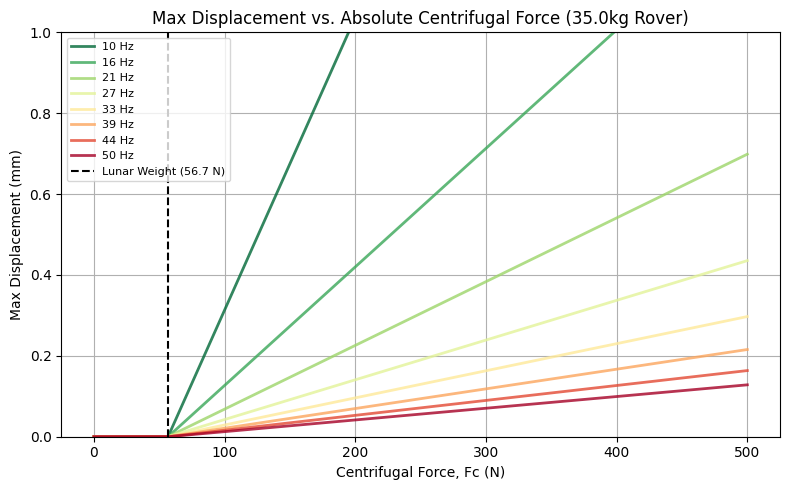

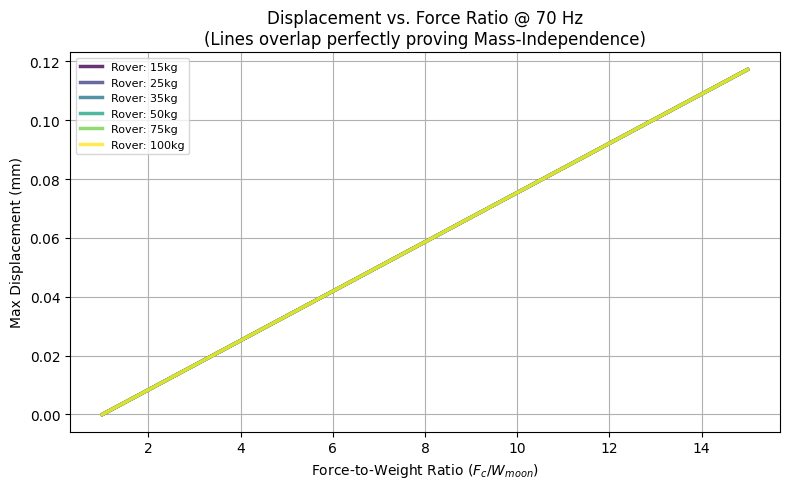

In [9]:
# PLOT B: Displacement vs Centrifugal Force
Fc_abs = np.linspace(0, 500, 500)
figB, axB = plt.subplots(figsize=(8, 5))

frequencies_plotB = np.linspace(10, 50, 8)
colors_plotB = plt.cm.RdYlGn_r(np.linspace(0, 1, len(frequencies_plotB)))

for freq, color in zip(frequencies_plotB, colors_plotB):
    axB.plot(Fc_abs, micro_bounce(Fc_abs, freq), color=color, lw=2, label=f'{freq:.0f} Hz', alpha=0.8)

axB.axvline(x=W_m_default, color='k', linestyle='--', label=f'Lunar Weight ({W_m_default:.1f} N)')
axB.set_title(f'Max Displacement vs. Absolute Centrifugal Force ({m_r_default}kg Rover)')
axB.set_xlabel('Centrifugal Force, Fc (N)')
axB.set_ylabel('Max Displacement (mm)')
axB.set_ylim(0, 1.0)
axB.grid(True)
axB.legend(fontsize=8)
plt.tight_layout()
plt.show()

# PLOT C: Mass Independence - Displacement vs Force Ratio 
Fc_ratio = np.linspace(1, 15, 500)
figC, axC = plt.subplots(figsize=(8, 5))

masses_plotC = [15, 25, 35, 50, 75, 100]
colors_plotC = plt.cm.viridis(np.linspace(0, 1, len(masses_plotC)))
f_test = 70 

for m, c in zip(masses_plotC, colors_plotC):
    W = m * g_m
    Fc_scaled = Fc_ratio * W
    axC.plot(Fc_ratio, micro_bounce(Fc_scaled, f_test, m), color=c, lw=2.5, alpha=0.8, label=f'Rover: {m}kg')

axC.set_title(f'Displacement vs. Force Ratio @ {f_test} Hz\n(Lines overlap perfectly proving Mass-Independence)')
axC.set_xlabel('Force-to-Weight Ratio ($F_c / W_{moon}$)')
axC.set_ylabel('Max Displacement (mm)')
axC.grid(True)
axC.legend(fontsize=8)
plt.tight_layout()
plt.show()

While the rover's bounce is mass-independent relative to its weight ratio, soil compaction is not. Lunar simulant relative density is driven by absolute yield stress. A 100 kg rover applying a Force Ratio of 2.0 generates vastly more absolute crushing force than a 15 kg rover at the same ratio. Consequently, heavier rovers reach terminal locked-soil density much earlier on the non-dimensionalized curve. Furthermore, classical soil mechanics dictates that compaction effort (number of passes) is asymptotically bounded by the applied force. 
$$N = -\frac{1}{k_{comp}} \ln\left(1 - \frac{D_r - D_{min}}{D_{limit}(F_c) - D_{min}}\right)$$
If the dynamic force is insufficient to overcome the soil's yield stress at a certain density, infinite passes will result in purely elastic deformation without further plastic volume reduction.

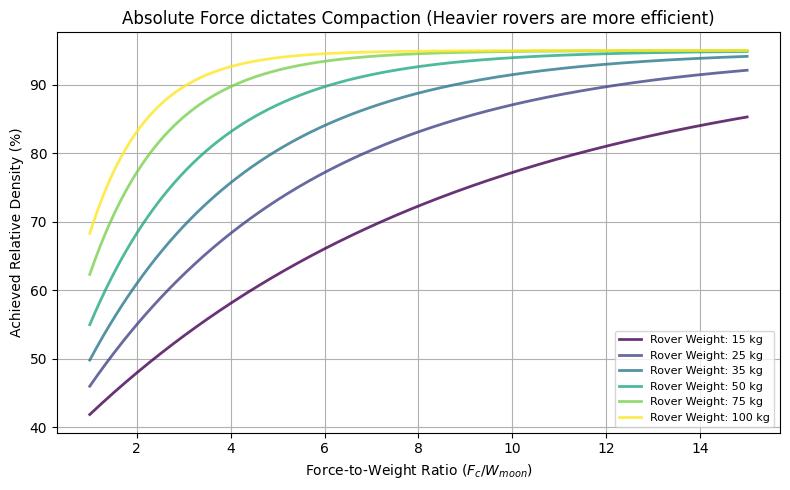

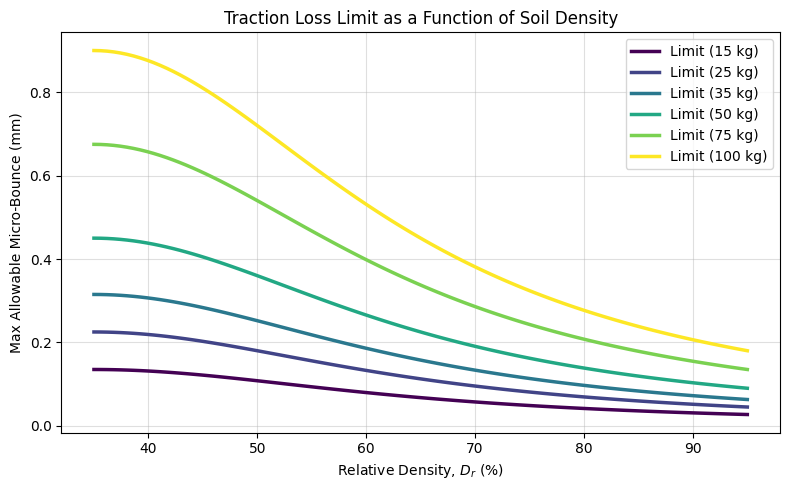

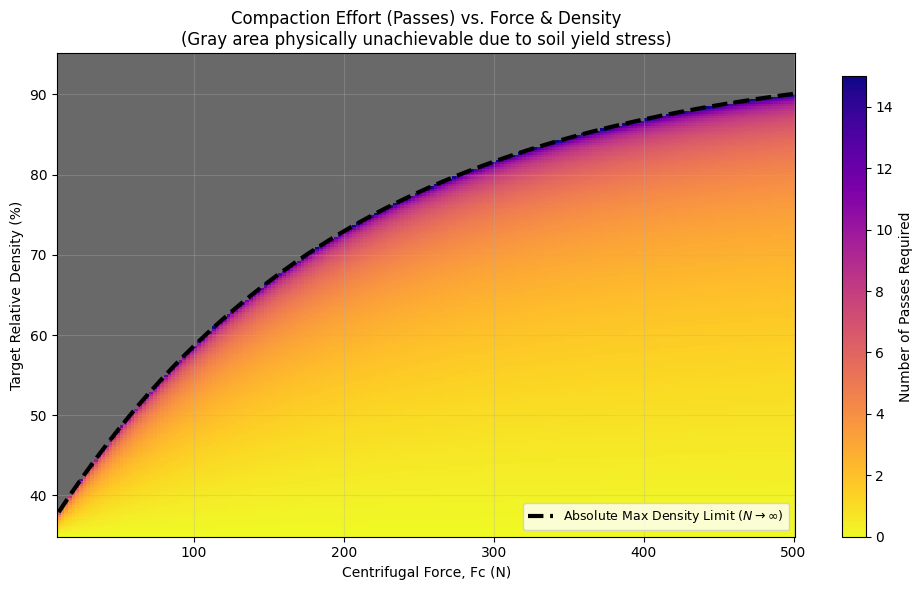

In [10]:

# PLOT D: Density vs Force Ratio for Different Weights 

figD, axD = plt.subplots(figsize=(8, 5))

for m, c in zip(masses_plotC, colors_plotC):
    W = m * g_m
    Fc_array = Fc_ratio * W
    Dr_array = relative_density(Fc_array)
    axD.plot(Fc_ratio, Dr_array * 100, color=c, lw=2, label=f'Rover Weight: {m} kg', alpha=0.8)

axD.set_xlabel('Force-to-Weight Ratio ($F_c / W_{moon}$)')
axD.set_ylabel('Achieved Relative Density (%)')
axD.set_title('Absolute Force dictates Compaction (Heavier rovers are more efficient)')
axD.grid(True)
axD.legend(fontsize=8)
plt.tight_layout()
plt.show()



Dr_array = np.linspace(0.35, 0.95, 100)

fig11, ax11 = plt.subplots(figsize=(8, 5))

for m, color in zip(masses_plotC, colors_plotC):
    X_lim_array = critical_rebound_limit(Dr_array, m)
    ax11.plot(Dr_array * 100, X_lim_array, color=color, lw=2.5, label=f'Limit ({m} kg)')

ax11.set_xlabel('Relative Density, $D_r$ (%)')
ax11.set_ylabel('Max Allowable Micro-Bounce (mm)')
ax11.set_title('Traction Loss Limit as a Function of Soil Density')
ax11.grid(True, alpha=0.4)
ax11.legend()
fig11.tight_layout()
plt.show()


# PLOT E: Heatmap of Passes vs Centrifugal Force and Relative Density

Fc_vals = np.linspace(10, 500, 200) 
Dr_vals = np.linspace(0.35, 0.95, 200)
F_grid_E, D_grid_E = np.meshgrid(Fc_vals, Dr_vals)

# Calculate asymptotic limit for each Fc
Dr_inf = relative_density(F_grid_E)

# Compaction rate constant (~90% achieved in 6 passes)
k_compaction = 0.4 

# Mask out unreachable densities (Yield Stress Limit)
reachable_mask = D_grid_E < Dr_inf
N_grid = np.full_like(F_grid_E, np.nan)

# Calculate passes for reachable area
fraction = (D_grid_E[reachable_mask] - 0.35) / (Dr_inf[reachable_mask] - 0.35)
fraction = np.clip(fraction, 0, 0.9999) 
N_grid[reachable_mask] = - (1 / k_compaction) * np.log(1 - fraction)

figE, axE = plt.subplots(figsize=(10, 6))
cmapE = plt.get_cmap('plasma_r').copy()
cmapE.set_bad(color='dimgray') # Unachievable zone

imE = axE.pcolormesh(F_grid_E, D_grid_E * 100, N_grid, cmap=cmapE, shading='auto', vmin=0, vmax=15)
axE.plot(Fc_vals, relative_density(Fc_vals) * 100, 'k--', lw=3, label='Absolute Max Density Limit ($N \\rightarrow \\infty$)')

axE.set_xlabel('Centrifugal Force, Fc (N)')
axE.set_ylabel('Target Relative Density (%)')
axE.set_title('Compaction Effort (Passes) vs. Force & Density\n(Gray area physically unachievable due to soil yield stress)')
cbarE = figE.colorbar(imE, ax=axE, label='Number of Passes Required')
cbarE.extend = 'max'
axE.grid(True, alpha=0.3)
axE.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### Mass-Dependent Traction Limits
Because heavier rovers reach high relative density at lower force ratios, their soil matrix locks into a rigid state faster. This rigidity crushes the elastic rebound limit from 0.5 mm down to 0.1 mm.

Therefore, while the actual physical bounce (solid lines) is mass-independent, the traction loss limit (dashed lines) is strictly mass-dependent. The intersection of these two realities defines the ultimate 3D design envelope for the system.

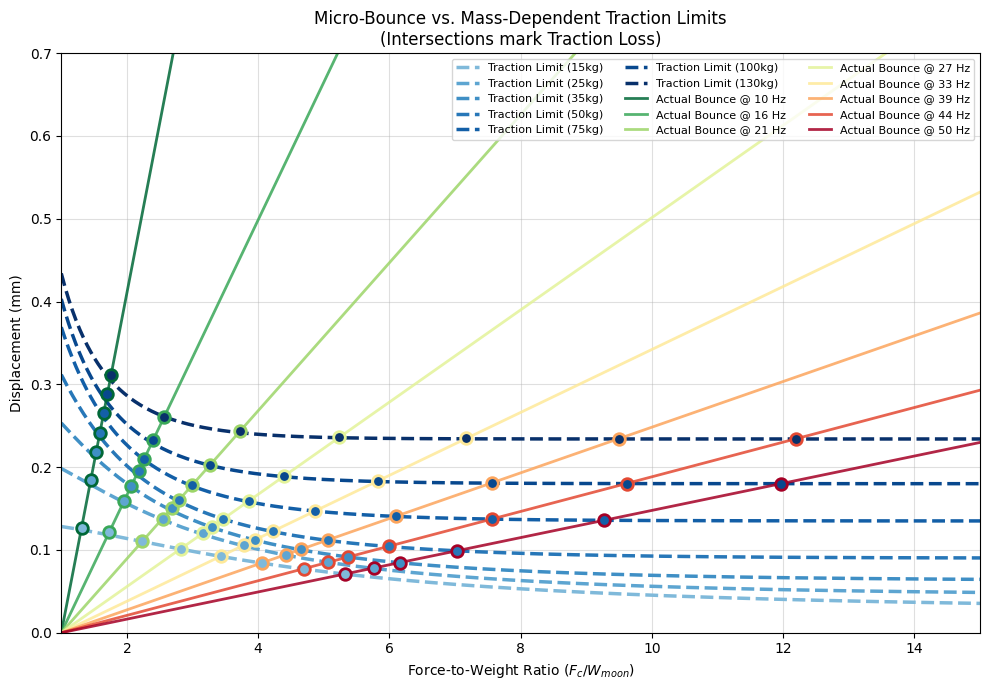

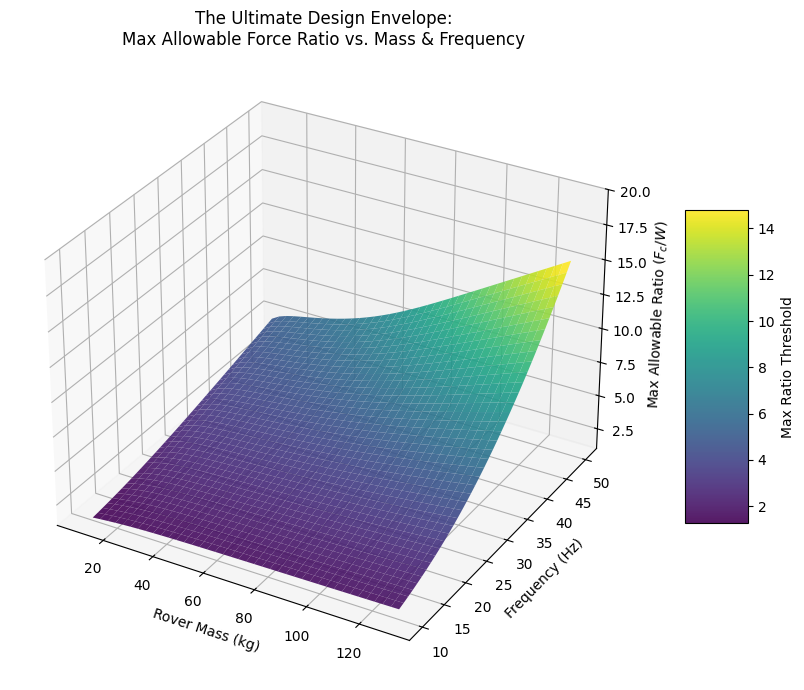

In [11]:

# PLOT F: Micro-Bounce vs. Mass-Dependent Traction Limits

figF, axF = plt.subplots(figsize=(10, 7))

masses = [15, 25, 35, 50, 75, 100, 130]
mass_colors = plt.cm.Blues(np.linspace(0.45, 1.0, len(masses)))
limit_colors = {m: c for m, c in zip(masses, mass_colors)}

for m in masses:
    Fc = Fc_ratio * m * g_m
    Dr = relative_density(Fc)
    X_limit = critical_rebound_limit(Dr, m)
    axF.plot(Fc_ratio, X_limit, color=limit_colors[m], linestyle='--', lw=2.5, label=f'Traction Limit ({m}kg)')

frequencies_plotF = np.linspace(10, 50, 8)
freq_colors_plotF = plt.cm.RdYlGn_r(np.linspace(0, 1, len(frequencies_plotF)))

for f, c in zip(frequencies_plotF, freq_colors_plotF):
    w = 2 * np.pi * f
    bounce = (np.maximum(0, Fc_ratio - 1) * g_m) / (w**2) * 1000
    axF.plot(Fc_ratio, bounce, color=c, lw=2.0, alpha=0.85, label=f'Actual Bounce @ {f:.0f} Hz')
    
    for m in masses:
        Fc = Fc_ratio * m * g_m
        Dr = relative_density(Fc)
        X_limit = critical_rebound_limit(Dr, m)
        diff = X_limit - bounce
        if np.any(diff < 0):
            idx = np.where(diff < 0)[0][0]
            axF.scatter(Fc_ratio[idx], bounce[idx], color=limit_colors[m], edgecolor=c, linewidth=2, s=70, zorder=5)

axF.set_xlabel('Force-to-Weight Ratio ($F_c / W_{moon}$)')
axF.set_ylabel('Displacement (mm)')
axF.set_ylim(0, 0.7)
axF.set_xlim(1, 15)
axF.set_title('Micro-Bounce vs. Mass-Dependent Traction Limits\n(Intersections mark Traction Loss)')
axF.grid(True, alpha=0.4)
axF.legend(loc='upper right', fontsize=8, ncol=3)
plt.tight_layout()
plt.show()


# PLOT G: 3D Boundary Surface (Mass vs Freq vs Max Ratio)

figG = plt.figure(figsize=(10, 7))
axG = figG.add_subplot(111, projection='3d')

M_grid_3d, F_grid_3d = np.meshgrid(np.linspace(10, 130, 40), np.linspace(10, 50, 40))
Max_R_grid = np.zeros_like(M_grid_3d)

for i in range(M_grid_3d.shape[0]):
    for j in range(M_grid_3d.shape[1]):
        m = M_grid_3d[i, j]
        f = F_grid_3d[i, j]
        
        low, high = 1.0, 30.0
        for _ in range(25): 
            mid = (low + high) / 2
            b = micro_bounce(mid * m * g_m, f, m)
            l = critical_rebound_limit(relative_density(mid * m * g_m), m)
            if b < l:
                low = mid
            else:
                high = mid
        Max_R_grid[i, j] = low

surfG = axG.plot_surface(M_grid_3d, F_grid_3d, Max_R_grid, cmap='viridis', edgecolor='none', alpha=0.9)
axG.set_title('The Ultimate Design Envelope:\nMax Allowable Force Ratio vs. Mass & Frequency')
axG.set_xlabel('Rover Mass (kg)')
axG.set_ylabel('Frequency (Hz)')
axG.set_zlabel('Max Allowable Ratio ($F_c/W$)')
axG.set_zlim(1, 20)
figG.colorbar(surfG, shrink=0.5, aspect=5, label='Max Ratio Threshold')
plt.tight_layout()
plt.show()

C:\Users\varun\AppData\Local\Temp\ipykernel_46220\3846929895.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  figH.tight_layout(rect=[0, 0, 1, 0.96])


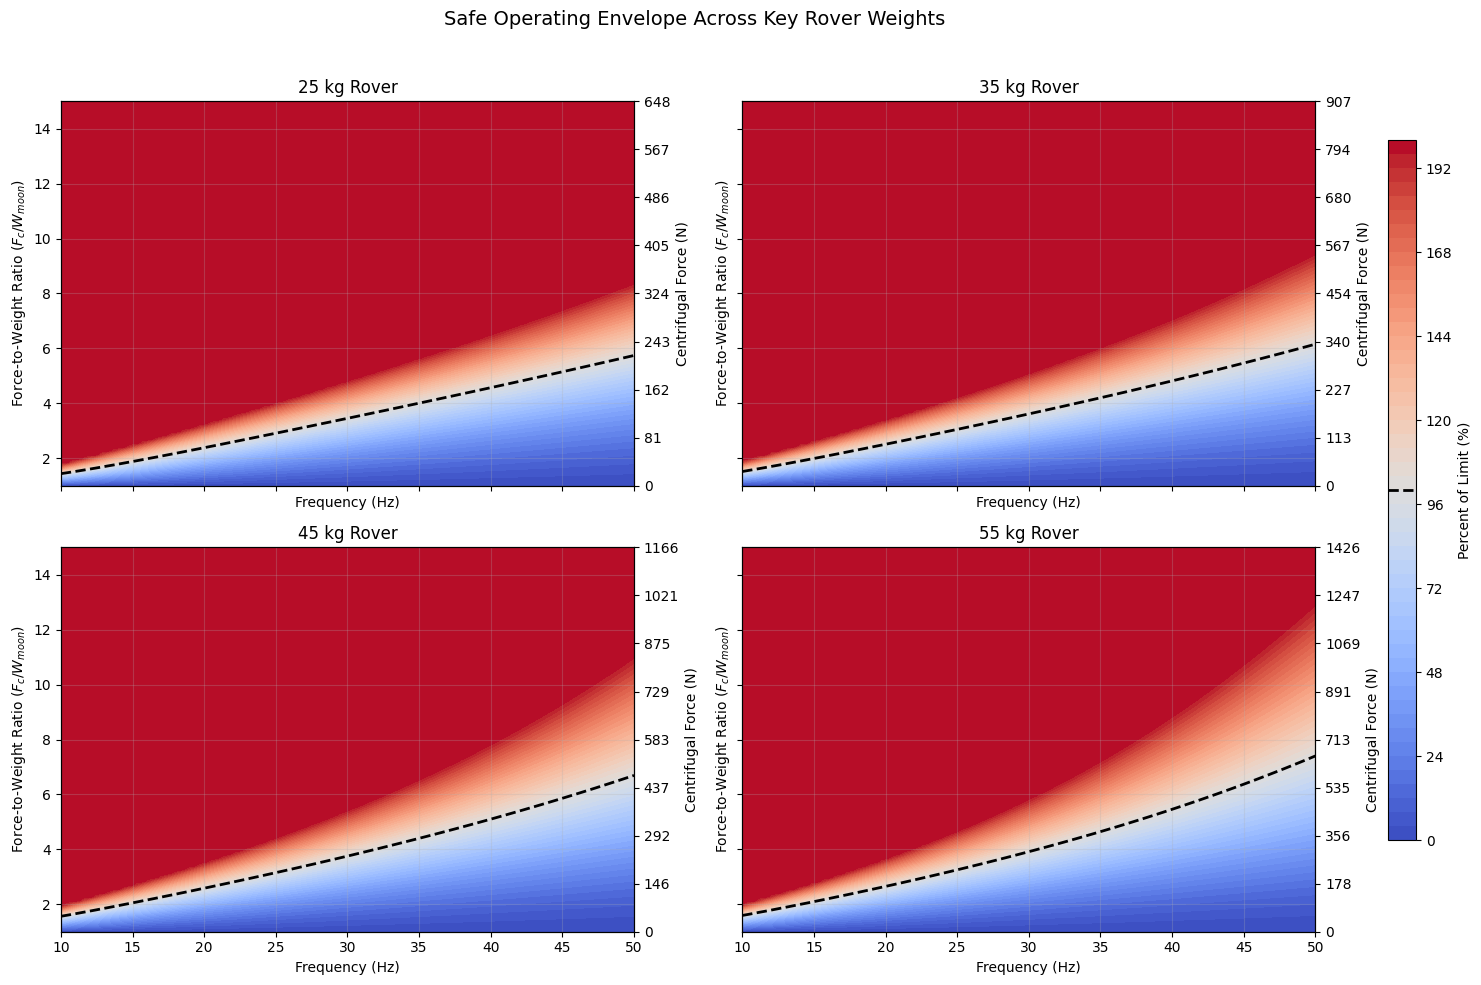

In [12]:
# PLOT H: Safe Operating Envelope for Key Rover Weights

%matplotlib inline

weights = [25, 35, 45, 55]
frequencies_grid = np.linspace(10, 50, 100)
ratios_grid = np.linspace(1, 15, 100)
F_grid, R_grid = np.meshgrid(frequencies_grid, ratios_grid)

cmapH = plt.get_cmap('coolwarm')
normH = mcolors.TwoSlopeNorm(vmin=0, vcenter=100, vmax=200)

figH, axesH = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axesH = axesH.ravel()

for ax, m in zip(axesH, weights):
    Fc_grid = R_grid * m * g_m
    B_grid = micro_bounce(Fc_grid, F_grid, m)
    L_grid = critical_rebound_limit(relative_density(Fc_grid), m)
    P_grid = np.clip((B_grid / L_grid) * 100, 0, 200)

    contour = ax.contourf(F_grid, R_grid, P_grid, levels=50, cmap=cmapH, norm=normH)
    ax.contour(F_grid, R_grid, P_grid, levels=[100], colors='k', linewidths=2.0, linestyles='--')

    ax.set_xlim(10, 50)
    ax.set_ylim(1, 15)
    ax.set_title(f'{m} kg Rover')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Force-to-Weight Ratio ($F_c / W_{moon}$)')
    ax.grid(True, alpha=0.25)

    # Right axis maps ratio to centrifugal force for the selected rover mass
    ax_force = ax.twinx()
    ax_force.set_ylim(ax.get_ylim())
    ax_force.yaxis.set_label_position('right')
    ax_force.yaxis.tick_right()
    yticks = ax.get_yticks()
    ax_force.set_yticks(yticks)
    ax_force.set_yticklabels([f'{tick * m * g_m:.0f}' for tick in yticks])
    ax_force.set_ylabel('Centrifugal Force (N)')
    ax_force.grid(False)

figH.suptitle('Safe Operating Envelope Across Key Rover Weights', fontsize=14)

# Reserve room on the right and place a dedicated vertical colorbar there
figH.subplots_adjust(right=0.88, top=0.90)
caxH = figH.add_axes([0.995, 0.15, 0.02, 0.70])  # [left, bottom, width, height]
caxH.set_in_layout(False)

cbarH = figH.colorbar(contour, cax=caxH, label='Percent of Limit (%)')
cbarH.ax.axhline(100, color='k', lw=2, linestyle='--')

figH.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### References

**Terramechanics and Soil Stiffness**

1. **Wong, J. Y. (2001). *Theory of Ground Vehicles* (3rd ed.). John Wiley & Sons.** * *Application:* Fundamental derivation of the unloading curve ($P = k_u \times z_e$) used to define the elastic rebound and the maximum allowable micro-bounce before traction loss.
2. **Hardin, B. O., & Black, W. L. (1968). "Vibration modulus of normally consolidated clay." *Journal of the Soil Mechanics and Foundations Division*, 94(2), 353-369.**
   * *Application:* Geomechanical proof that the unloading stiffness modulus ($k_u$) of granular materials scales quadratically as the soil transitions from a loose state to a highly compacted state. Used to dynamically link $k_u$ to Relative Density ($D_r$).

**Vibratory Compaction and Roller Dynamics**

3. **Forssblad, L. (1981). *Vibratory soil and rock fill compaction*. Dynapac Maskin AB.**
   * *Application:* Established the empirical models proving that relative density approaches an absolute, force-dependent asymptote ($D_{r,\infty}$), rather than scaling infinitely with the force-to-weight ratio.
4. **D'Appolonia, D. J., Whitman, R. V., & D'Appolonia, E. (1969). "Sand compaction with vibratory rollers." *Journal of the Soil Mechanics and Foundations Division*, 95(1), 263-284.**
   * *Application:* Derived the logarithmic multi-pass compaction curve ($N$ passes) showing that volume reduction ceases once the dynamic stress falls below the soil's internal yield stress.
5. **Mooney, M. A., & Adam, D. (2007). "Vibratory Roller Responses during Compaction." *Journal of Geotechnical and Geoenvironmental Engineering*.**
   * *Application:* Validation of the "Double Jump" and roller hopping thresholds. Confirmed that continuous contact is lost at sub-millimeter elastic deflection limits, even for heavy compaction equipment.

**Lunar Simulant Geomechanics**

6. **Agarwal, A., et al. (2024). "Compaction Testing on Lunar Highland Simulant Using a Vibrating Drum Roller." *ASCE Earth & Space Conference Proceedings*.**
   * *Application:* Empirical validation of vibratory fluidization frequencies, centrifugal force limits, and compaction behaviors specifically scaled for Exolith LHS-1 Lunar Highland Simulant.
7. **Alshibli, K. A., & Hasan, A. (2009). "Strength properties of JSC-1A lunar regolith simulant." *Journal of Geotechnical and Geoenvironmental Engineering*, 135(5), 673-679.**
   * *Application:* Baseline material properties for lunar regolith simulants, validating the extreme compressibility in loose states versus the rapid stiffening (interlocking) under compaction.